In [11]:
from google.colab import files

uploaded = files.upload()

print(uploaded.keys())

dict_keys([])


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42
N_SPLITS = 5

train_df = pd.read_csv("train.csv")

print(train_df.shape)
train_df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [13]:
X = train_df.drop(columns=["SalePrice", "Id"])

y_raw = train_df["SalePrice"]

y = np.log1p(y_raw)

print(X.shape)
print(y.shape)
print(y_raw.min(), y_raw.max())

(1460, 79)
(1460,)
34900 755000


In [14]:
X_dev, X_holdout, y_dev, y_holdout = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Development features:", X_dev.shape)
print("Held-out features:", X_holdout.shape)
print("Development target:", y_dev.shape)
print("Held-out target:", y_holdout.shape)

Development features: (1168, 79)
Held-out features: (292, 79)
Development target: (1168,)
Held-out target: (292,)


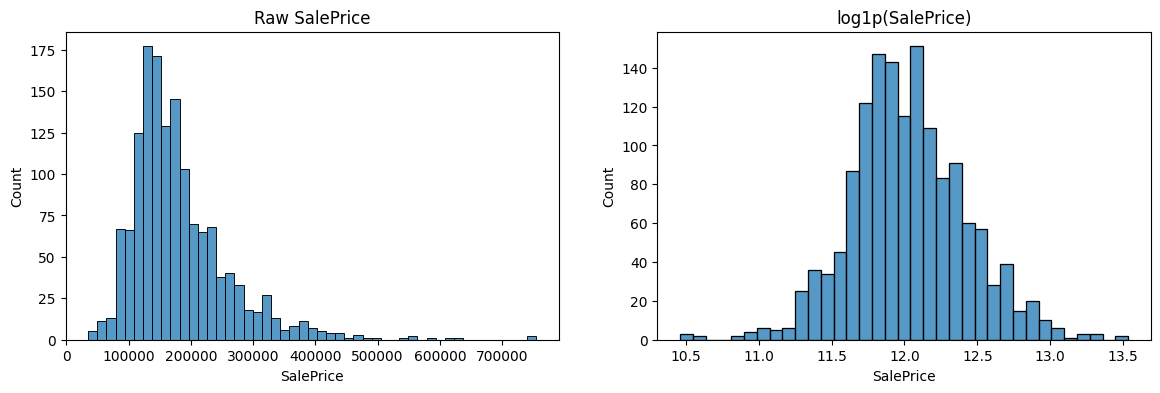

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(y_raw, ax=axes[0])
axes[0].set_title("Raw SalePrice")

sns.histplot(y, ax=axes[1])
axes[1].set_title("log1p(SalePrice)")

plt.show()

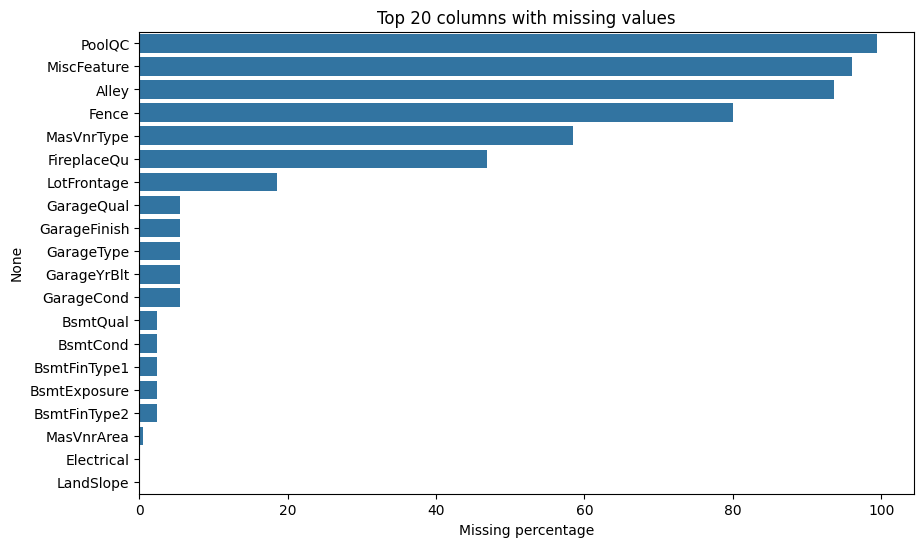

In [16]:
missing_values = X_dev.isna().mean().sort_values(ascending=False).head(20) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.values, y=missing_values.index)
plt.xlabel("Missing percentage")
plt.title("Top 20 columns with missing values")
plt.show()

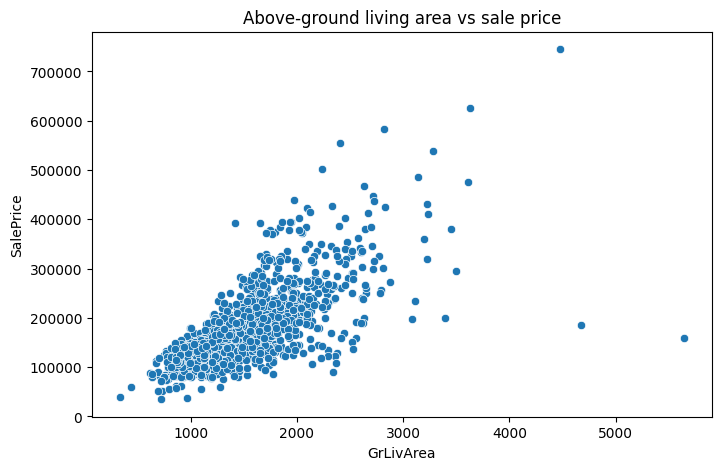

In [17]:
eda_data = train_df.loc[X_dev.index]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=eda_data, x="GrLivArea", y="SalePrice")
plt.title("Above-ground living area vs sale price")
plt.show()

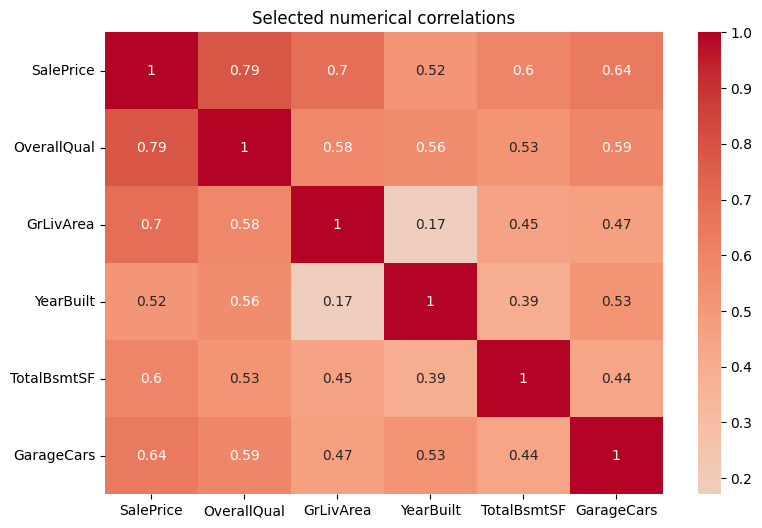

In [18]:
correlation_columns = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "YearBuilt",
    "TotalBsmtSF",
    "GarageCars"

]

plt.figure(figsize=(9, 6))
sns.heatmap(
    eda_data[correlation_columns].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Selected numerical correlations")
plt.show()

In [19]:
class AmesFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        def num(column):
            if column in X.columns:
                return pd.to_numeric(X[column], errors="coerce")
            return 0

        X["MSSubClass"] = X["MSSubClass"].astype(str)

        X["TotalSF"] = (
            num("TotalBsmtSF")
            + num("1stFlrSF")
            + num("2ndFlrSF")
        )

        X["TotalBath"] = (
            num("FullBath")
            + 0.5 * num("HalfBath")
            + num("BsmtFullBath")
            + 0.5 * num("BsmtHalfBath")
        )

        X["HouseAge"] = num("YrSold") - num("YearBuilt")

        X["YearsSinceRemodel"] = (
            num("YrSold")
            - num("YearRemodAdd")
        )

        X["TotalPorchSF"] = (
            num("OpenPorchSF")
            + num("EnclosedPorch")
            + num("3SsnPorch")
            + num("ScreenPorch")
        )

        return X

In [20]:
def get_column_groups(X):
    X_transformed = AmesFeatureEngineer().fit_transform(X)

    categorical_columns = X_transformed.select_dtypes(
        include=["object"]
    ).columns.tolist()

    numeric_columns = [
        column
        for column in X_transformed.columns
        if column not in categorical_columns
    ]

    low_cardinality_columns = [
        column
        for column in categorical_columns
        if X_transformed[column].nunique(dropna=True) <= 14
    ]

    high_cardinality_columns = [
        column
        for column in categorical_columns
        if X_transformed[column].nunique(dropna=True) > 14
    ]

    return (
        numeric_columns,
        low_cardinality_columns,
        high_cardinality_columns
    )

In [21]:
numeric_columns, low_cardinality_columns, high_cardinality_columns = get_column_groups(X_dev)

print("Numeric columns:", len(numeric_columns))
print("Low-cardinality categorical columns:", len(low_cardinality_columns))
print("High-cardinality categorical columns:", len(high_cardinality_columns))

print(high_cardinality_columns)

Numeric columns: 40
Low-cardinality categorical columns: 40
High-cardinality categorical columns: 4
['MSSubClass', 'Neighborhood', 'Exterior1st', 'Exterior2nd']


In [22]:
def build_pipeline(model, X_reference):
    numeric_columns, low_cardinality_columns, high_cardinality_columns = get_column_groups(X_reference)

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    low_cardinality_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    high_cardinality_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target_encoder", TargetEncoder(
            target_type="continuous",
            smooth="auto",
            cv=5,
            shuffle=True,
            random_state=RANDOM_STATE
        ))
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("low_cardinality", low_cardinality_pipeline, low_cardinality_columns),
        ("high_cardinality", high_cardinality_pipeline, high_cardinality_columns)
    ])

    pipeline = Pipeline([
        ("feature_engineering", AmesFeatureEngineer()),
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    return pipeline

In [23]:
cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [24]:
def log_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [27]:
def make_oof_predictions(model, X, y, cv):
    predictions = np.zeros(len(X))
    fold_scores = []

    for fold, (train_index, valid_index) in enumerate(cv.split(X), start=1):
        X_train = X.iloc[train_index]
        X_valid = X.iloc[valid_index]

        y_train = y.iloc[train_index]
        y_valid = y.iloc[valid_index]

        pipeline = build_pipeline(clone(model), X_train)

        pipeline.fit(X_train, y_train)

        valid_predictions = pipeline.predict(X_valid)

        predictions[valid_index] = valid_predictions

        score = log_rmse(y_valid, valid_predictions)

        fold_scores.append(score)

        print(f"Fold {fold}: {score:.5f}")

    return predictions, fold_scores